In [55]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [56]:
ratio = 50
rooth_path = f"/home/csartor1/code/NODS/results/plus_area/{ratio}"
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"

In [57]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))
# heatmaps of number of spikes for every PC
cell = 'pc_spikes'
time_bin = 50
trial_len = between_start
n_sim = 5
pc_ids = np.arange(71,170)

In [58]:
result_path = rooth_path+"/wo_NO/4Hz/"
pc_spikes_matrix_trial_2 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30 = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff = np.nan*np.ones((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30 = np.median(pc_spikes_matrix_trial_30,axis = 2)
pc_spikes_matrix_trial_2 = np.median(pc_spikes_matrix_trial_2,axis = 2)
pc_spikes_matrix_trial_diff = pc_spikes_matrix_trial_30 - pc_spikes_matrix_trial_2
pc_change = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change[:,i] = pc_spikes_matrix_trial_diff[:,5]-pc_spikes_matrix_trial_diff[:,2+i]

pc_change_median = pc_spikes_matrix_trial_diff[:,5] - np.median(pc_spikes_matrix_trial_diff[:,2:5], axis =1)
pc_change_cr_bs = pc_spikes_matrix_trial_diff[:,5] - pc_spikes_matrix_trial_diff[:,3]

In [59]:
result_path = rooth_path+"/w_NO/4Hz/"
pc_spikes_matrix_trial_2_60 = np.zeros((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_30_60 = np.zeros((len(pc_ids),int(trial_len/time_bin),n_sim))
pc_spikes_matrix_trial_diff_60 = np.zeros((len(pc_ids),int(trial_len/time_bin),n_sim))
trial_len = between_start
for k in range(0,n_sim):
    file_path = result_path+f'sim_{k}/'
    spk = get_spike_activity(cell_name=cell, path=file_path)
    times = spk[:,1]
    ID_cell = spk[:,0].astype(int)

    intervals = [(500,1000), (14500,15000)]
    for i,interval in enumerate(intervals):
        for j,t_interval in enumerate(range(interval[0],interval[1],time_bin)):
            start = t_interval
            end = t_interval+time_bin
            mask = (times >= start) & (times <= end)
            filtered_ids = ID_cell[mask]


            for id in np.unique(filtered_ids):
                count_spikes = len(np.where(filtered_ids==id)[0])
                ind_pc_id = np.where(pc_ids == id)[0]
                if i == 0:
                    pc_spikes_matrix_trial_2_60[ind_pc_id,j,k] = count_spikes
                else:
                    pc_spikes_matrix_trial_30_60[ind_pc_id,j,k] = count_spikes

pc_spikes_matrix_trial_30_60 = np.median(pc_spikes_matrix_trial_30_60,axis = 2)
pc_spikes_matrix_trial_2_60 = np.median(pc_spikes_matrix_trial_2_60,axis = 2)
pc_spikes_matrix_trial_diff_60 = pc_spikes_matrix_trial_30_60 - pc_spikes_matrix_trial_2_60

pc_change_60 = np.zeros((len(pc_ids),3))
for i in range(3):
    pc_change_60[:,i] = pc_spikes_matrix_trial_diff_60[:,5]-pc_spikes_matrix_trial_diff_60[:,2+i]

pc_change_median_60 = pc_spikes_matrix_trial_diff_60[:,5] - np.median(pc_spikes_matrix_trial_diff_60[:,2:5], axis =1)
pc_change_cr_bs_60 = pc_spikes_matrix_trial_diff_60[:,5] - pc_spikes_matrix_trial_diff_60[:,3]

In [60]:
import pickle
with open(f"/home/csartor1/code/NODS/data/pfs-PC_CS_{ratio}.pkl", 'rb') as file:
    pfs_PC_CS = pickle.load(file)

num_syn = np.zeros((len(pc_ids)))
for pf_PC in pfs_PC_CS:
    pc_ind = np.where(pc_ids == pf_PC[1])[0]
    num_syn[pc_ind] += 1

/tmp/ipykernel_458177/746453482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Plasticity", y="Spike Count Delta", data=data, palette={"Standard STDP": "blue", "NO STDP": "green"})


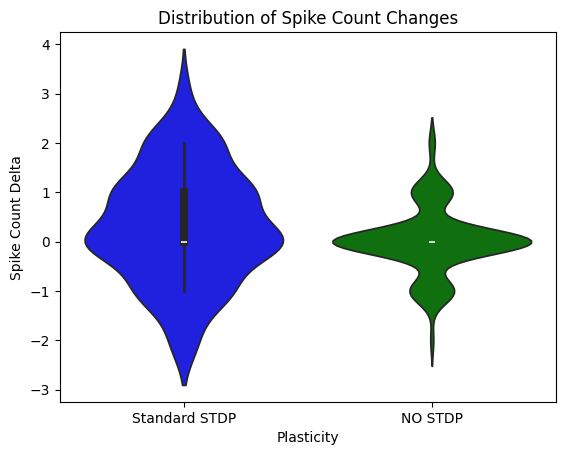

In [61]:
import seaborn as sns
# Combine data for seaborn
data = {
    "Plasticity": ['Standard STDP'] * len(pc_change[:,1]) + ['NO STDP'] * len(pc_change_60[:,1]),
    "Spike Count Delta": np.concatenate([pc_change[:,1], pc_change_60[:,1]]),
}

sns.violinplot(x="Plasticity", y="Spike Count Delta", data=data, palette={"Standard STDP": "blue", "NO STDP": "green"})
plt.title('Distribution of Spike Count Changes')
plt.show()

In [62]:
from scipy.stats import pearsonr

# Correlation for Group 1
r1, p1 = pearsonr(num_syn, pc_change[:,1])
print(f'Standard STDP Correlation: r={r1:.2f}, p={p1:.2e}')

# Correlation for Group 2
r2, p2 = pearsonr(num_syn, pc_change_60[:,1])
print(f'NO STDP Correlation: r={r2:.2f}, p={p2:.2e}')

Standard STDP Correlation: r=0.38, p=1.01e-04
NO STDP Correlation: r=0.09, p=3.56e-01


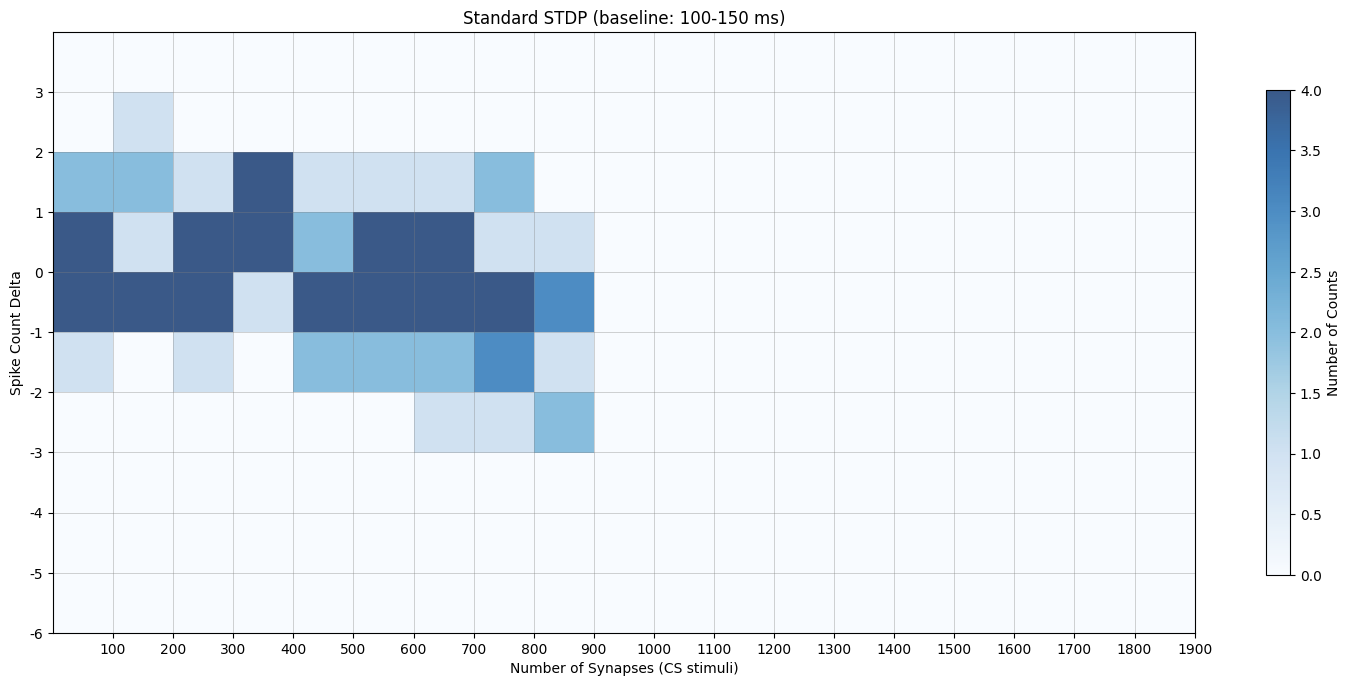

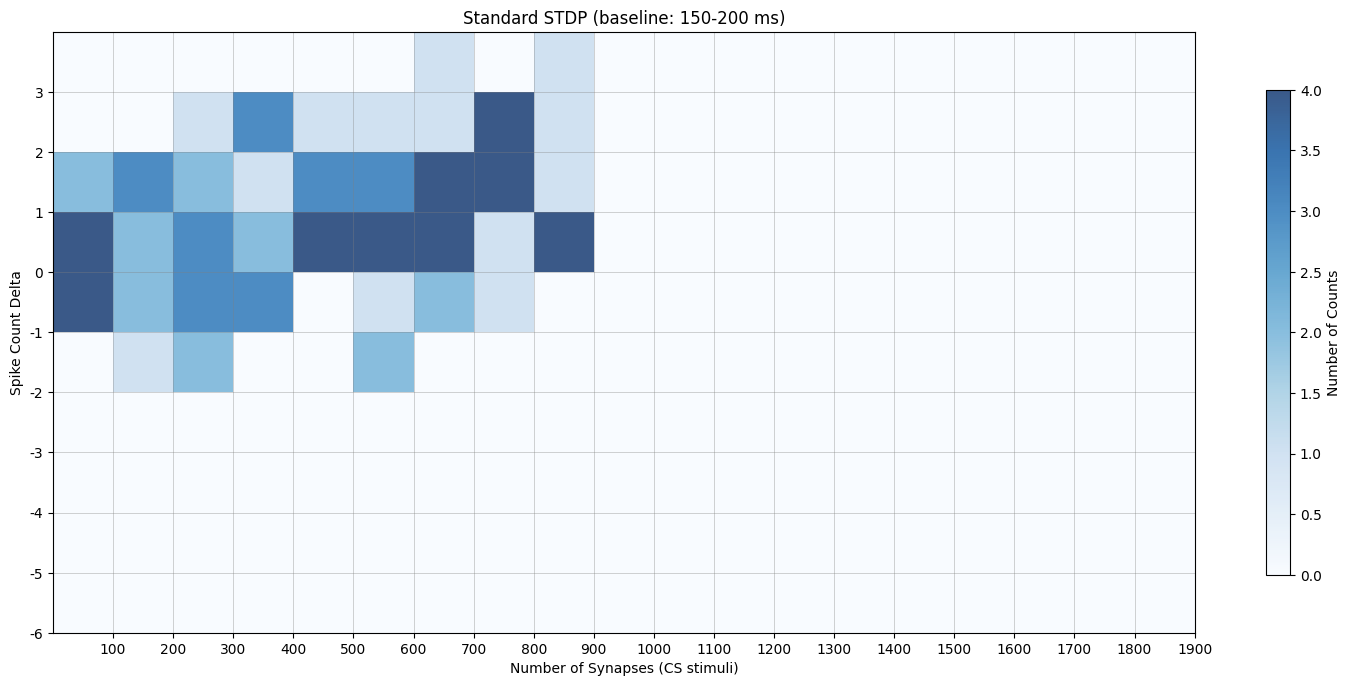

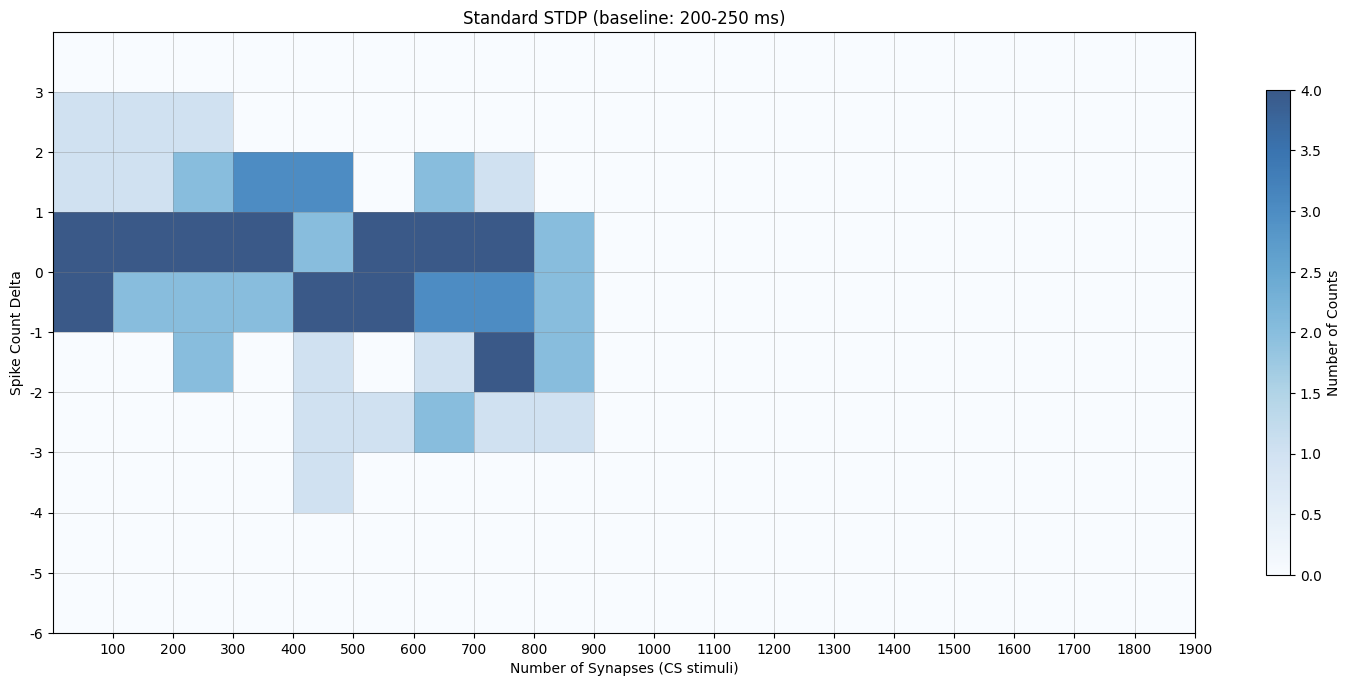

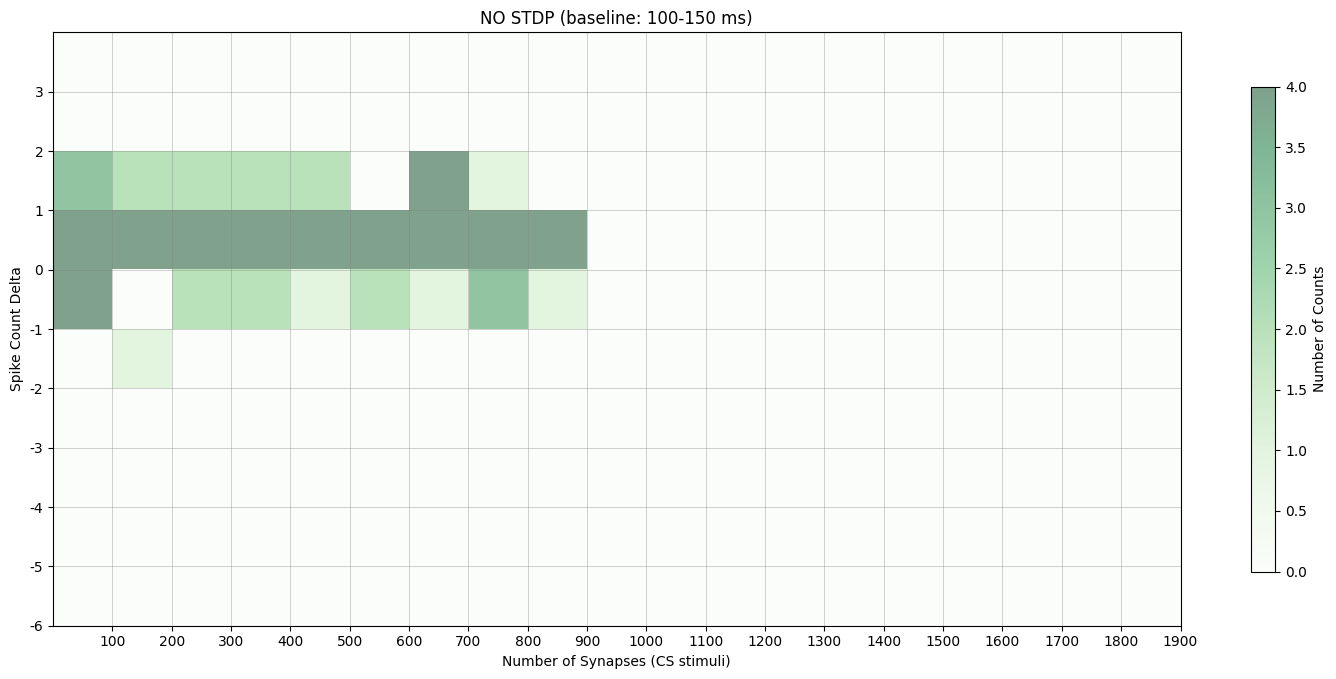

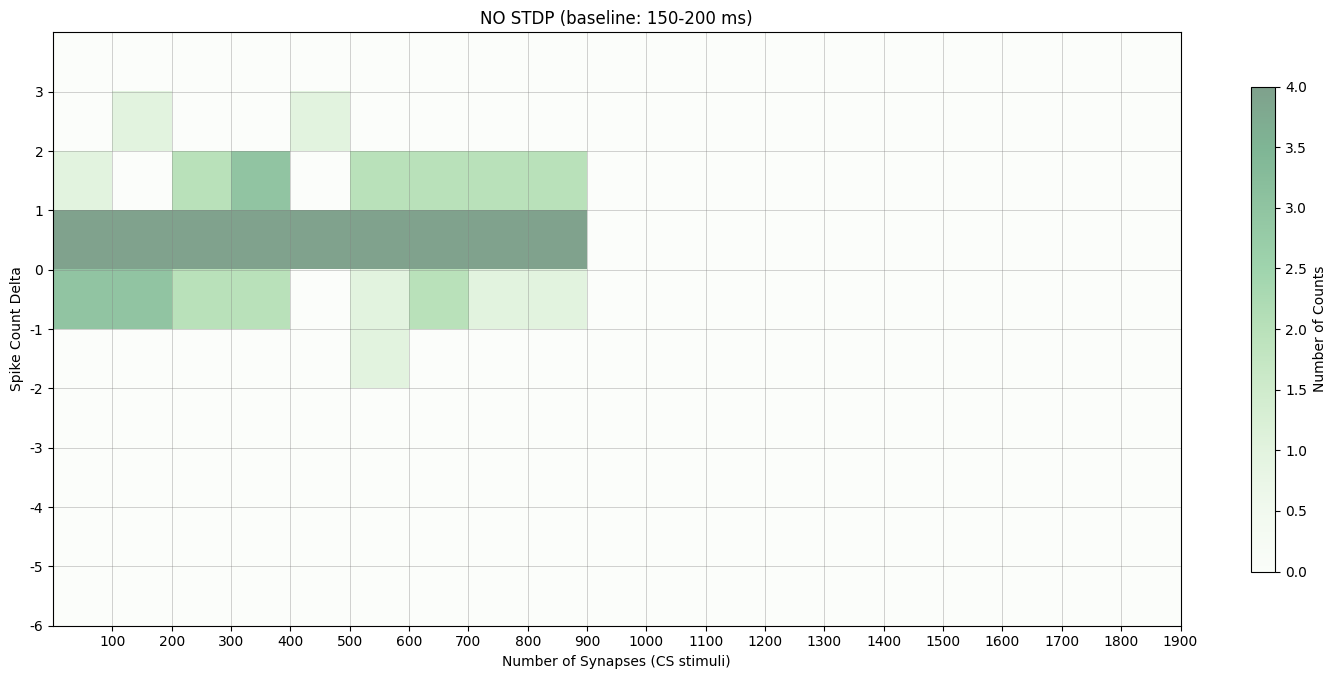

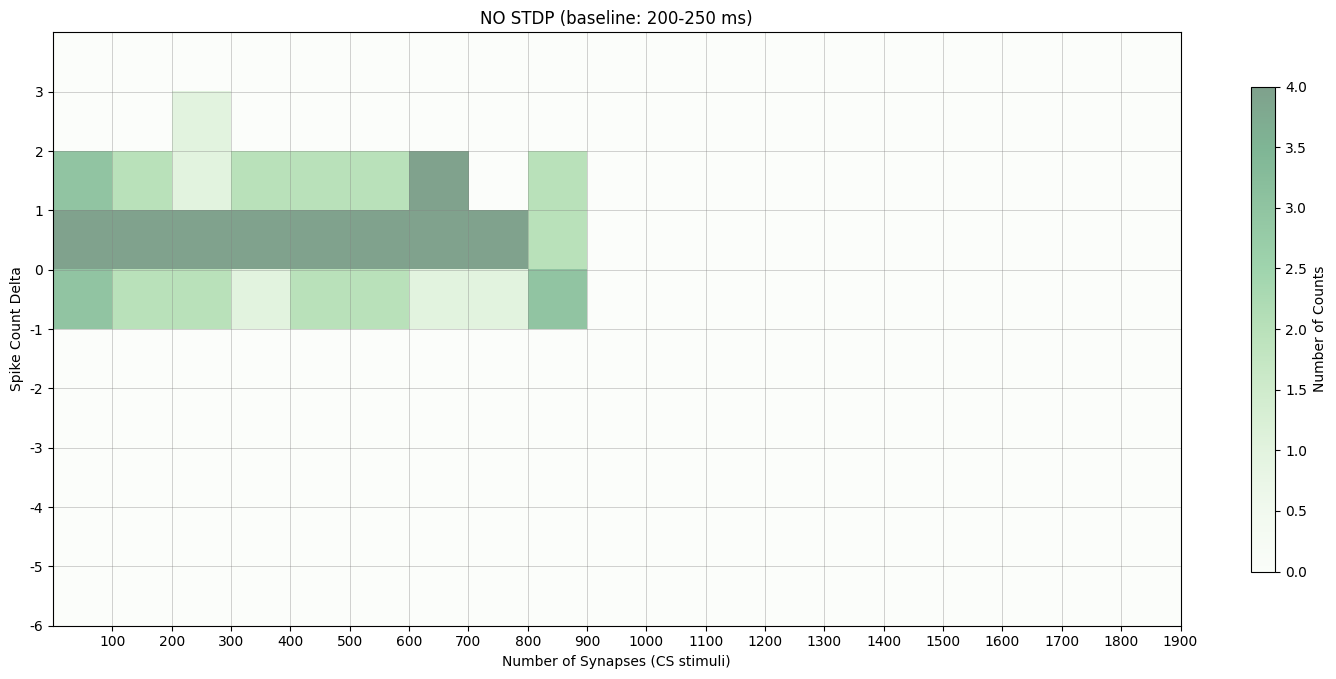

In [63]:
syn_bins = np.arange(0, 2000, 100)
delta_bins = np.arange(-6, 5, 1)
reversed_delta_bins = delta_bins[::-1]
delta_time = [(100,150),(150,200),(200,250)]

for i,times in enumerate(delta_time):
    plt.figure(figsize=(15, 10))
    matrix = np.zeros((len(delta_bins) - 1, len(syn_bins) - 1))
    for synapses, spike_delta in zip(num_syn, pc_change[:,i]):
        synapse_bin_idx = np.digitize(synapses, syn_bins) - 1  # Synapse bin index
        delta_bin_idx = np.digitize(spike_delta, delta_bins) - 1  # Spike delta bin index
        
        if (0 <= synapse_bin_idx < len(syn_bins) - 1) and (0 <= delta_bin_idx < len(delta_bins) - 1):
            # Assign a value (use count or another aggregation if needed)
            matrix[delta_bin_idx, synapse_bin_idx] += 1

    # Create the heatmap
    matrix = np.flipud(matrix)
    plt.imshow(matrix, cmap='Blues', alpha=0.8, label='Standard STDP', vmax=4, vmin = 0)
    plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.xticks(ticks=np.arange(0.5, len(syn_bins)-1, 1),labels=syn_bins[1:])
    plt.yticks(ticks=np.arange(0.5, len(delta_bins)-1, 1),labels=reversed_delta_bins[1:])
    plt.title(f'Standard STDP (baseline: {times[0]}-{times[1]} ms)')
    plt.xlabel('Number of Synapses (CS stimuli)')
    plt.ylabel('Spike Count Delta')
    plt.grid(color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    plt.tight_layout()
    #plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.show()

for i,times in enumerate(delta_time):
    plt.figure(figsize=(15, 10))
    matrix = np.zeros((len(delta_bins) - 1, len(syn_bins) - 1))
    for synapses, spike_delta in zip(num_syn, pc_change_60[:,i]):
        synapse_bin_idx = np.digitize(synapses, syn_bins) - 1  # Synapse bin index
        delta_bin_idx = np.digitize(spike_delta, delta_bins) - 1  # Spike delta bin index
        
        if (0 <= synapse_bin_idx < len(syn_bins) - 1) and (0 <= delta_bin_idx < len(delta_bins) - 1):
            # Assign a value (use count or another aggregation if needed)
            matrix[delta_bin_idx, synapse_bin_idx] += 1

    matrix = np.flipud(matrix)
    plt.imshow(matrix, cmap='Greens', alpha=0.5, label='NO-STDP', vmax=4, vmin = 0)
    plt.xticks(ticks=np.arange(0.5, len(syn_bins)-1, 1),labels=syn_bins[1:])
    plt.yticks(ticks=np.arange(0.5, len(delta_bins)-1, 1),labels=reversed_delta_bins[1:])
    plt.title(f'NO STDP (baseline: {times[0]}-{times[1]} ms)')
    plt.xlabel('Number of Synapses (CS stimuli)')
    plt.ylabel('Spike Count Delta')
    plt.grid(color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.colorbar(label='Number of Counts', shrink=0.5)
    plt.show()